**Connect Google Drive**


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**Set Project Path**

In [1]:
PROJECT_PATH = "/Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet"

**Import Libraries**

In [3]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

**Load Saved Dataset**

In [8]:
images = np.load(os.path.join(PROJECT_PATH, "images.npy"))
labels = np.load(os.path.join(PROJECT_PATH, "labels.npy"))

#Print dataset shapes
print(images.shape)
print(labels.shape)

(54305, 224, 224, 3)
(54305,)


**Check Total Classes**

In [9]:
#Get unique class names
unique_classes = np.unique(labels)

print("Total Classes:", len(unique_classes))   #Print total classes

print(unique_classes)   #Print class names

Total Classes: 38
['Apple___Apple_scab' 'Apple___Black_rot' 'Apple___Cedar_apple_rust'
 'Apple___healthy' 'Blueberry___healthy'
 'Cherry_(including_sour)___Powdery_mildew'
 'Cherry_(including_sour)___healthy'
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'
 'Corn_(maize)___Common_rust_' 'Corn_(maize)___Northern_Leaf_Blight'
 'Corn_(maize)___healthy' 'Grape___Black_rot'
 'Grape___Esca_(Black_Measles)'
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)' 'Grape___healthy'
 'Orange___Haunglongbing_(Citrus_greening)' 'Peach___Bacterial_spot'
 'Peach___healthy' 'Pepper,_bell___Bacterial_spot'
 'Pepper,_bell___healthy' 'Potato___Early_blight' 'Potato___Late_blight'
 'Potato___healthy' 'Raspberry___healthy' 'Soybean___healthy'
 'Squash___Powdery_mildew' 'Strawberry___Leaf_scorch'
 'Strawberry___healthy' 'Tomato___Bacterial_spot' 'Tomato___Early_blight'
 'Tomato___Late_blight' 'Tomato___Leaf_Mold' 'Tomato___Septoria_leaf_spot'
 'Tomato___Spider_mites Two-spotted_spider_mite' 'Tomato___Target_Sp

In this it identifies all unique disease categories present in the dataset.

**Show Sample Images**

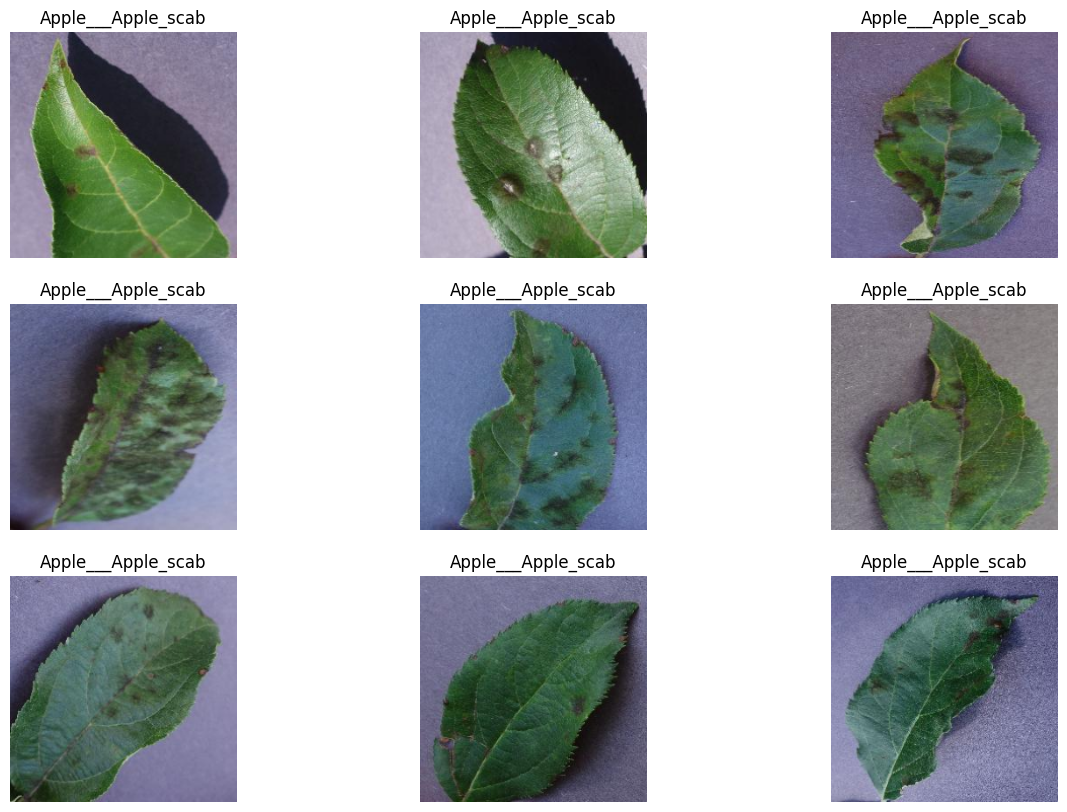

In [10]:
#Create figure window
plt.figure(figsize=(15,10))

#Show first 9 images
for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(labels[i])

    plt.axis("off")

plt.show()

Displays sample plant leaf images along with their labels. It helps visually inspect image quality, disease patterns, dataset correctness

**Class Distribution**

In [11]:
#Count images in every class
class_counts = Counter(labels)

#Store class names
class_names = list(class_counts.keys())

#Store image counts
counts = list(class_counts.values())

print(class_counts)   #Print class distribution

Counter({np.str_('Orange___Haunglongbing_(Citrus_greening)'): 5507, np.str_('Tomato___Tomato_Yellow_Leaf_Curl_Virus'): 5357, np.str_('Soybean___healthy'): 5090, np.str_('Peach___Bacterial_spot'): 2297, np.str_('Tomato___Bacterial_spot'): 2127, np.str_('Tomato___Late_blight'): 1909, np.str_('Squash___Powdery_mildew'): 1835, np.str_('Tomato___Septoria_leaf_spot'): 1771, np.str_('Tomato___Spider_mites Two-spotted_spider_mite'): 1676, np.str_('Apple___healthy'): 1645, np.str_('Tomato___healthy'): 1591, np.str_('Blueberry___healthy'): 1502, np.str_('Pepper,_bell___healthy'): 1478, np.str_('Tomato___Target_Spot'): 1404, np.str_('Grape___Esca_(Black_Measles)'): 1383, np.str_('Corn_(maize)___Common_rust_'): 1192, np.str_('Grape___Black_rot'): 1180, np.str_('Corn_(maize)___healthy'): 1162, np.str_('Strawberry___Leaf_scorch'): 1109, np.str_('Grape___Leaf_blight_(Isariopsis_Leaf_Spot)'): 1076, np.str_('Cherry_(including_sour)___Powdery_mildew'): 1052, np.str_('Potato___Early_blight'): 1000, np.st

Counts how many images belong to each disease category. Which helps to detects class imbalance,
overrepresented classes,
underrepresented classes.

**Plot Class Distribution**

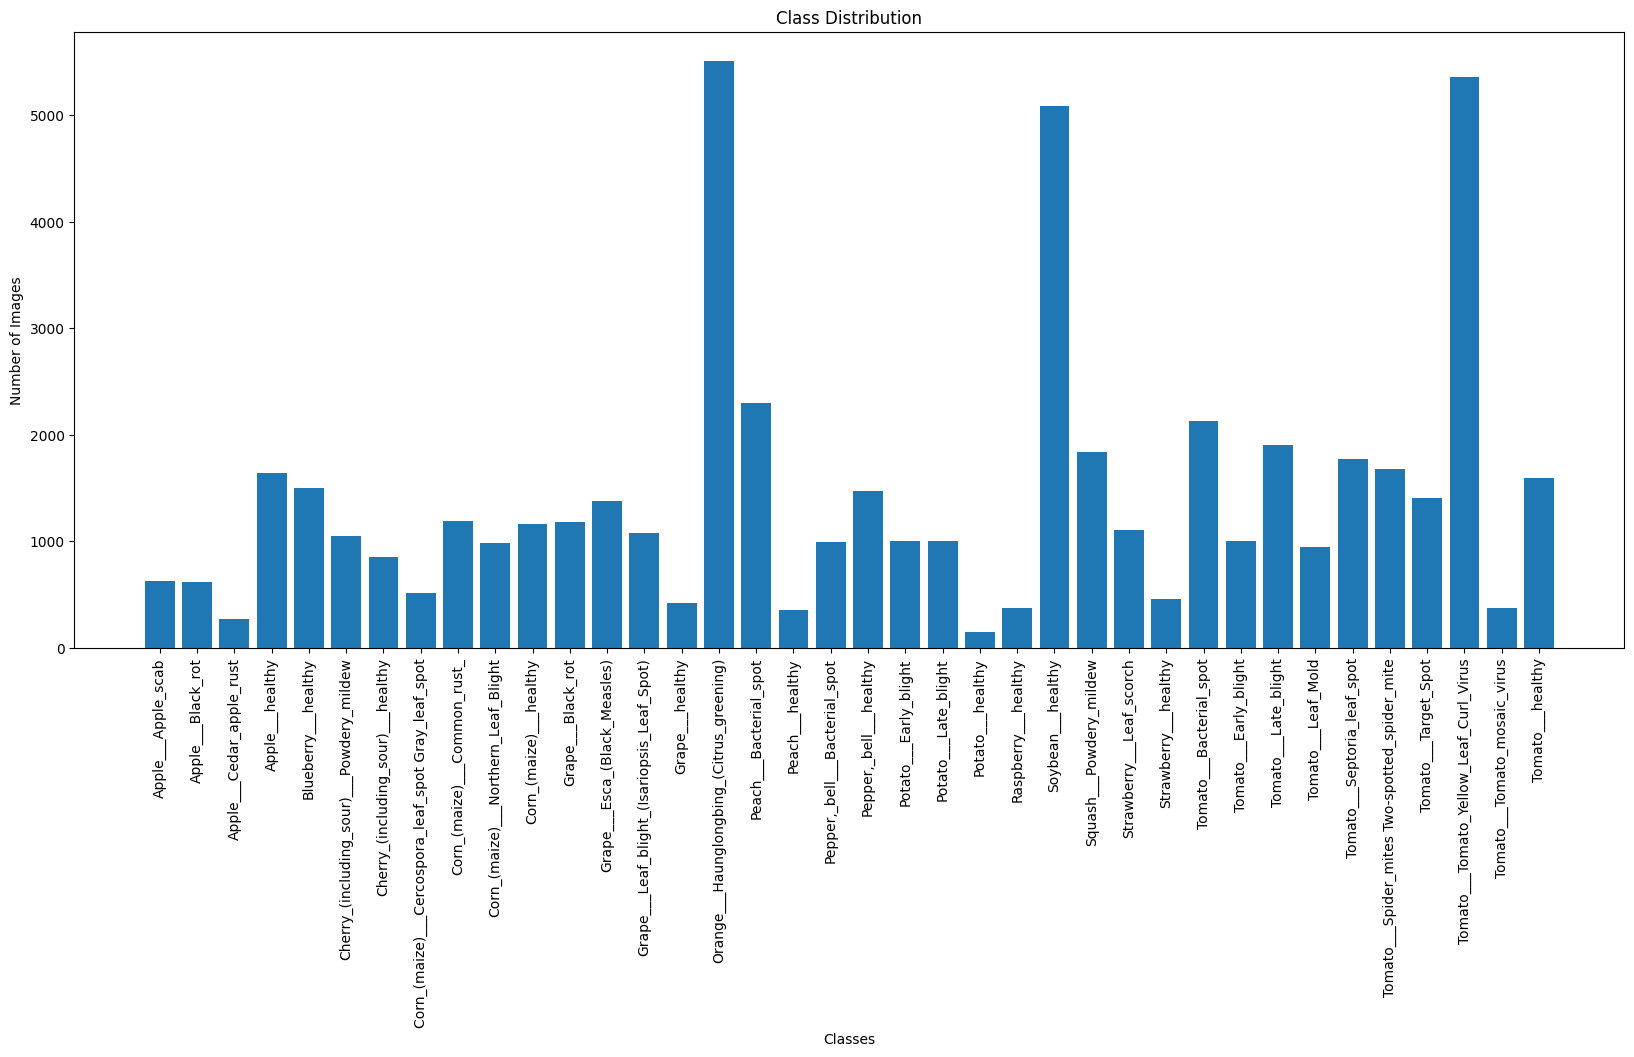

In [12]:
plt.figure(figsize=(20,8))   #Create graph

plt.bar(class_names, counts)   #Create bar chart

plt.xticks(rotation=90)   #Rotate class (x-axis) labels

plt.title("Class Distribution")   #Graph title

plt.xlabel("Classes")   #X-axis label

plt.ylabel("Number of Images")   #Y-axis label

plt.show()

It Shows dataset distribution visually using a bar chart.

reference - https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

**Check Image Shape**

In [13]:
#Print shape of first image
print("Image Shape:", images[0].shape)

Image Shape: (224, 224, 3)


Displays image dimensions.

**Check Image Data Type**

In [14]:
#Print image datatype
print(images.dtype)

uint8


It Shows how image pixels are stored. It is useful before normalization and model training.

**Comapre Healthy and Diseased Leaves**

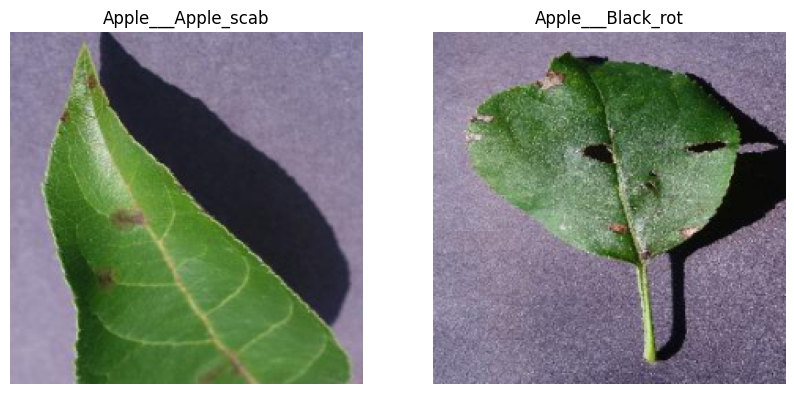

In [15]:
#Select sample image indexes
healthy_index = 0
disease_index = 1000

plt.figure(figsize=(10,5))   #Create figure

#Healthy leaf image
plt.subplot(1,2,1)
plt.imshow(images[healthy_index])
plt.title(labels[healthy_index])
plt.axis("off")

#Diseased leaf image
plt.subplot(1,2,2)
plt.imshow(images[disease_index])
plt.title(labels[disease_index])
plt.axis("off")

plt.show()

Displays comparison between healthy and diseased leaf samples. It helps to understand visible disease symptoms before augmentation and model training.

**Optional - Create Folder for Graphs**

In [18]:
#Create graphs folder
os.makedirs(
    f"{PROJECT_PATH}/graphs",
    exist_ok=True
)

print("graphs folder created!")

graphs folder created!


Creates a separate folder to save generated graphs.

**Save Class Distribution Graph**

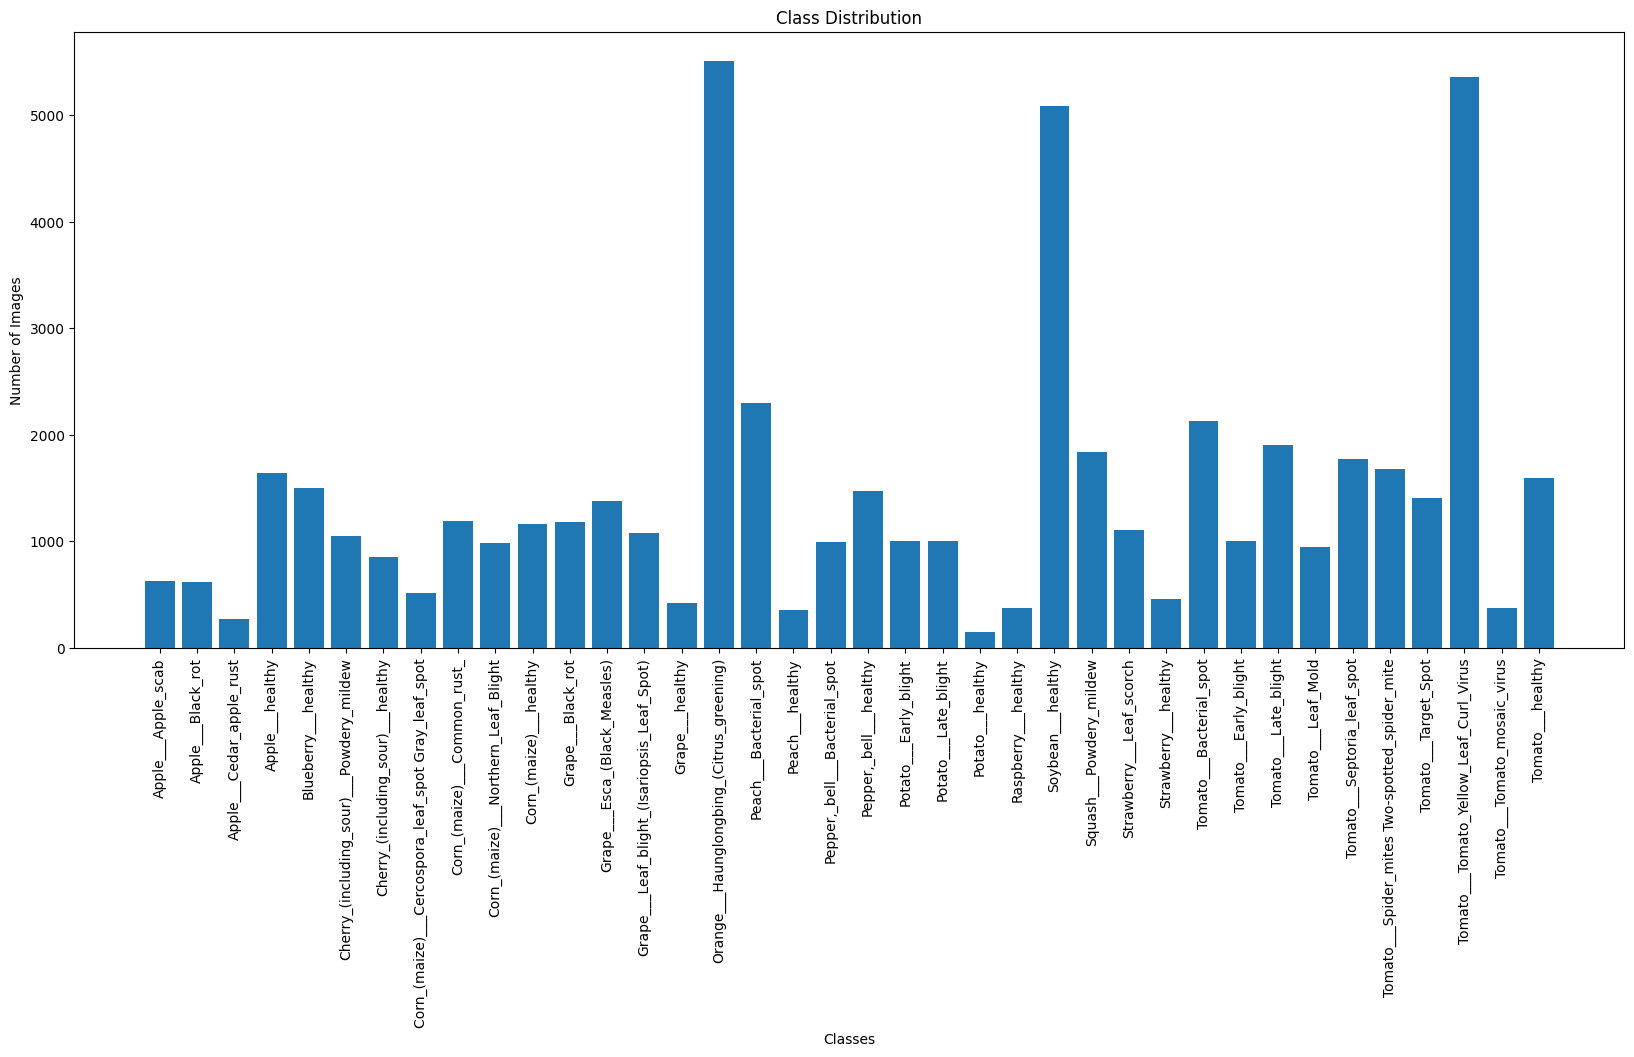

In [19]:
plt.figure(figsize=(20,8))   #Create graph

plt.bar(class_names, counts)   #Plot bar chart

plt.xticks(rotation=90)   #Rotate class names

plt.title("Class Distribution")   #Add graph title

#Axis labels
plt.xlabel("Classes")
plt.ylabel("Number of Images")

#Save graph
plt.savefig(
    f"{PROJECT_PATH}/graphs/class_distribution.png"
)

plt.show()

Saves the class distribution graph as an image file. Which is useful for thesis documentation, reports, presentations, result analysis.

reference -
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html
